In [2]:
import time
import re
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

BASE_URL = "https://books.toscrape.com/"
CATALOGUE_URL = BASE_URL + "catalogue/"
HEADERS = {"User-Agent": "Mozilla/5.0 (Scraper)"}

RATING_WORDS = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

## 1: Data Acquisition

In [3]:
def get_group(url):
    """Fetch a URL and return a BeautifulSoup object."""
    response = requests.get(url, headers=HEADERS)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")


def get_category_links():
    """Return a dict of {genre_name: category_index_url} for all genres on the site."""
    soup = get_group(BASE_URL)
    nav_links = soup.select("div.side_categories ul li ul li a")
    categories = {}
    for a in nav_links:
        genre = a.get_text(strip=True)
        href = a["href"]
        categories[genre] = BASE_URL + href
    return categories


def parse_book_card(card, genre):
    """Extract raw fields from a single book card, including raw stock text from its detail page."""
    title = card.h3.a["title"]
    price_raw = card.select_one(".price_color").text.strip()      
    rating_word = card.select_one(".star-rating")["class"][1]     

    relative_href = card.h3.a["href"]
    detail_url = CATALOGUE_URL + relative_href.replace("../../../", "")
    detail_soup = get_group(detail_url)
    availability_raw = detail_soup.select_one(".instock.availability").text.strip()  
    time.sleep(0.2)

    return {
        "title": title,
        "price_raw": price_raw,
        "rating_word": rating_word,
        "availability_raw": availability_raw,
        "genre": genre,
    }

def scrape_category(genre, start_url):
    """Walk every paginated listing page of one category and return a list of book dicts."""
    records = []
    url = start_url
    while url:
        soup = get_group(url)
        cards = soup.select("article.product_pod")
        for card in cards:
            records.append(parse_book_card(card, genre))

        next_link = soup.select_one("li.next a")
        if next_link:
            url = url.rsplit("/", 1)[0] + "/" + next_link["href"]
        else:
            url = None
        time.sleep(0.3)
    return records


def scrape_full_catalogue():
    """Scrape every genre in full and return all books as raw records."""
    categories = get_category_links()
    all_records = []
    print(f"Found {len(categories)} genres. Scraping...")

    for genre, url in categories.items():
        recs = scrape_category(genre, url)
        print(f"  {genre:<25s} {len(recs):>4d} books")
        all_records.extend(recs)

    return pd.DataFrame(all_records)

df = scrape_full_catalogue()
print(f"Collected {len(df)} books.")
print(df.head())

df.to_csv("books_raw.csv", index=False)

Found 50 genres. Scraping...
  Travel                      11 books
  Mystery                     32 books
  Historical Fiction          26 books
  Sequential Art              75 books
  Classics                    19 books
  Philosophy                  11 books
  Romance                     35 books
  Womens Fiction              17 books
  Fiction                     65 books
  Childrens                   29 books
  Religion                     7 books
  Nonfiction                 110 books
  Music                       13 books
  Default                    152 books
  Science Fiction             16 books
  Sports and Games             5 books
  Add a comment               67 books
  Fantasy                     48 books
  New Adult                    6 books
  Young Adult                 54 books
  Science                     14 books
  Poetry                      19 books
  Paranormal                   1 books
  Art                          8 books
  Psychology                   7 bo

## 2. Data Cleaning

In [4]:
df = pd.read_csv("books_raw.csv")
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 5)

Column types:
title               object
price_raw           object
rating_word         object
availability_raw    object
genre               object
dtype: object

Missing values per column:
title               0
price_raw           0
rating_word         0
availability_raw    0
genre               0
dtype: int64

First 5 rows:


,title,price_raw,rating_word,availability_raw,genre
0,It's Only the Himalayas,Â£45.17,Two,In stock (19 available),Travel
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Â£49.43,Four,In stock (15 available),Travel
2,See America: A Celebration of Our National Par...,Â£48.87,Three,In stock (14 available),Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,Â£36.94,Two,In stock (8 available),Travel
4,Under the Tuscan Sun,Â£37.33,Three,In stock (7 available),Travel


In [5]:
def fix(text):
    """Repair text that was UTF-8 but got mis-coded as Latin-1"""
    if not isinstance(text, str):
        return text
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text

df["title"]= df["title"].apply(fix)
df["price_raw"] = df["price_raw"].apply(fix)

df[["title", "price_raw"]].head()

,title,price_raw
0,It's Only the Himalayas,£45.17
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,£49.43
2,See America: A Celebration of Our National Par...,£48.87
3,Vagabonding: An Uncommon Guide to the Art of L...,£36.94
4,Under the Tuscan Sun,£37.33


In [6]:
df["price"] = (
    df["price_raw"]
    .str.replace("£", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df[["price_raw", "price"]].head())
print("\nAny missing prices?", df["price"].isnull().sum())

  price_raw  price
0    £45.17  45.17
1    £49.43  49.43
2    £48.87  48.87
3    £36.94  36.94
4    £37.33  37.33

Any missing prices? 0


In [8]:
df["rating"] = df["rating_word"].map(RATING_WORDS)
print(df[["rating_word", "rating"]].head())

unmapped = df[df["rating"].isnull()]["rating_word"].unique()
print("\nUnmapped rating word (should be empty):", unmapped)

  rating_word  rating
0         Two       2
1        Four       4
2       Three       3
3         Two       2
4       Three       3

Unmapped rating word (should be empty): []


In [9]:
def extract_stockCount(text):
    """Pull the number out of a string like 'In stock (19 available)'. Return 0 if no number is found."""
    match = re.search(r"\((\d+) available\)", text)
    return int(match.group(1)) if match else 0

df["stock_count"] = df["availability_raw"].apply(extract_stockCount)
df["in_stock"] = df["availability_raw"].str.contains("In stock", case=False, na=False)

df[["availability_raw", "stock_count", "in_stock"]].head()

,availability_raw,stock_count,in_stock
0,In stock (19 available),19,True
1,In stock (15 available),15,True
2,In stock (14 available),14,True
3,In stock (8 available),8,True
4,In stock (7 available),7,True


In [10]:
NOT_REAL_GENRES = ["Default", "Add a comment"]
print("Rows with a non-genre 'genre' value:", df["genre"].isin(NOT_REAL_GENRES).sum())
df = df[~df["genre"].isin(NOT_REAL_GENRES)].copy()
df["genre"] = df["genre"].str.strip().str.title()
df["title_clean"] = (
    df["title"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("\nRemaining unique genres:", df["genre"].nunique())
df[["title", "title_clean", "genre"]].head()

Rows with a non-genre 'genre' value: 219

Remaining unique genres: 48


,title,title_clean,genre
0,It's Only the Himalayas,It's Only the Himalayas,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel
2,See America: A Celebration of Our National Par...,See America: A Celebration of Our National Par...,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,Vagabonding: An Uncommon Guide to the Art of L...,Travel
4,Under the Tuscan Sun,Under the Tuscan Sun,Travel


'Default' and 'Add a comment' are not real genres, so I removed their 219 books. 781 books remain which is above the 200 minimum.

In [11]:
key_cols = ["title_clean", "price", "rating", "stock_count", "in_stock", "genre"]
print("Missing values:")
print(df[key_cols].isnull().sum())

before = len(df)
df = df.dropna(subset=key_cols)
print(f"\nDropped {before - len(df)} rows with missing key values.")

dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes}")
df = df.drop_duplicates()
print(f"\nFinal shape after cleaning: {df.shape}")

Missing values:
title_clean    0
price          0
rating         0
stock_count    0
in_stock       0
genre          0
dtype: int64

Dropped 0 rows with missing key values.
Fully duplicated rows: 0

Final shape after cleaning: (781, 10)


In [12]:
clean_df = df[["title_clean", "genre", "price", "rating", "stock_count", "in_stock"]].rename(
    columns={"title_clean": "title"}
)

clean_df = clean_df.reset_index(drop=True)

print(clean_df.info())
print("\nSample f cleaned data:")
clean_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        781 non-null    object 
 1   genre        781 non-null    object 
 2   price        781 non-null    float64
 3   rating       781 non-null    int64  
 4   stock_count  781 non-null    int64  
 5   in_stock     781 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 31.4+ KB
None

Sample f cleaned data:


,title,genre,price,rating,stock_count,in_stock
0,It's Only the Himalayas,Travel,45.17,2,19,True
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,49.43,4,15,True
2,See America: A Celebration of Our National Par...,Travel,48.87,3,14,True
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,8,True
4,Under the Tuscan Sun,Travel,37.33,3,7,True
5,A Summer In Europe,Travel,44.34,2,7,True
6,The Great Railway Bazaar,Travel,30.54,1,6,True
7,A Year in Provence (Provence #1),Travel,56.88,4,6,True
8,The Road to Little Dribbling: Adventures of an...,Travel,23.21,1,3,True
9,Neither Here nor There: Travels in Europe,Travel,38.95,3,3,True


In [13]:
clean_df.to_csv("books_clean.csv", index=False)
print("Saved cleaned dataset to books_clean.csv")

Saved cleaned dataset to books_clean.csv


## 3. Data Visualisation

In [14]:
chosen_genre = "Nonfiction"

assert chosen_genre in clean_df["genre"].unique(), f"{chosen_genre} not found in dataset"
print(f"Chosen genre: {chosen_genre} ({(clean_df['genre'] == chosen_genre).sum()} books)")

Chosen genre: Nonfiction (110 books)


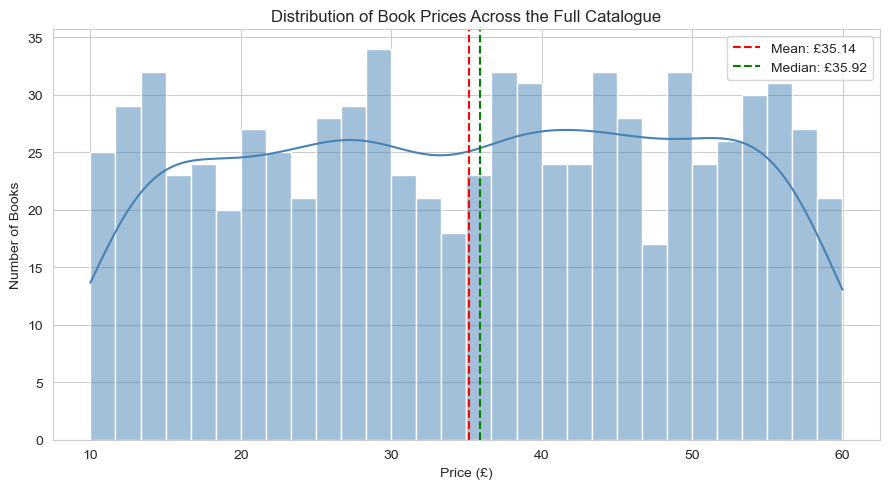

count    781.000000
mean      35.139949
std       14.507944
min       10.000000
25%       22.110000
50%       35.920000
75%       47.820000
max       59.990000
Name: price, dtype: float64


In [15]:
fig, ax = plt.subplots()
sns.histplot(clean_df["price"], bins=30, kde=True, color="steelblue", ax=ax)
ax.axvline(clean_df["price"].mean(), color="red", linestyle="--",
           label=f"Mean: £{clean_df['price'].mean():.2f}")
ax.axvline(clean_df["price"].median(), color="green", linestyle="--",
           label=f"Median: £{clean_df['price'].median():.2f}")
ax.set_title("Distribution of Book Prices Across the Full Catalogue")
ax.set_xlabel("Price (£)")
ax.set_ylabel("Number of Books")
ax.legend()
plt.tight_layout()
plt.show()

print(clean_df["price"].describe())

Prices run from 10 to 60 with a mean of 35.14 and a median of 35.92, so the distribution is fairly even.

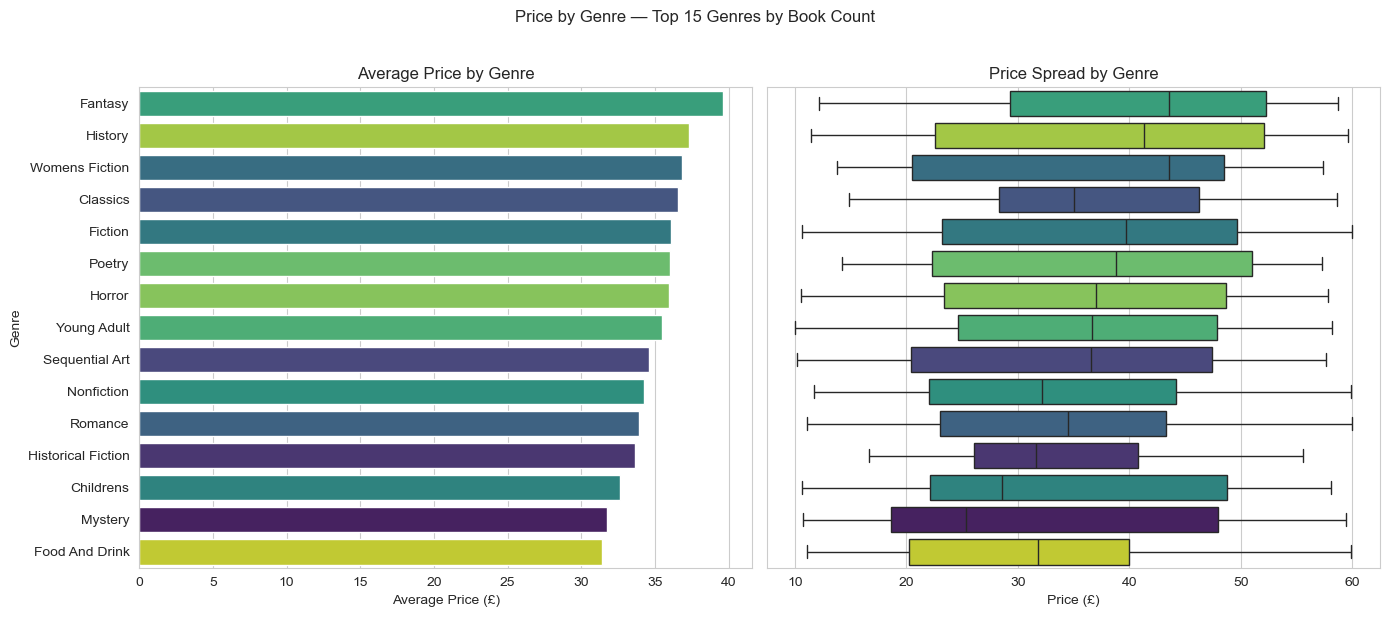

In [16]:
top_genres = clean_df["genre"].value_counts().head(15).index
top_df = clean_df[clean_df["genre"].isin(top_genres)]
order = top_df.groupby("genre")["price"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(data=top_df, x="price", y="genre", order=order, hue="genre",
            palette="viridis", legend=False, errorbar=None, ax=axes[0])
axes[0].set_title("Average Price by Genre")
axes[0].set_xlabel("Average Price (£)")
axes[0].set_ylabel("Genre")

sns.boxplot(data=top_df, x="price", y="genre", order=order, hue="genre",
            palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Price Spread by Genre")
axes[1].set_xlabel("Price (£)")
axes[1].set_ylabel("")

fig.suptitle("Price by Genre — Top 15 Genres by Book Count", y=1.02)
plt.tight_layout()
plt.show()

Average prices differ only slightly between genres and every genre has a wide of prices.

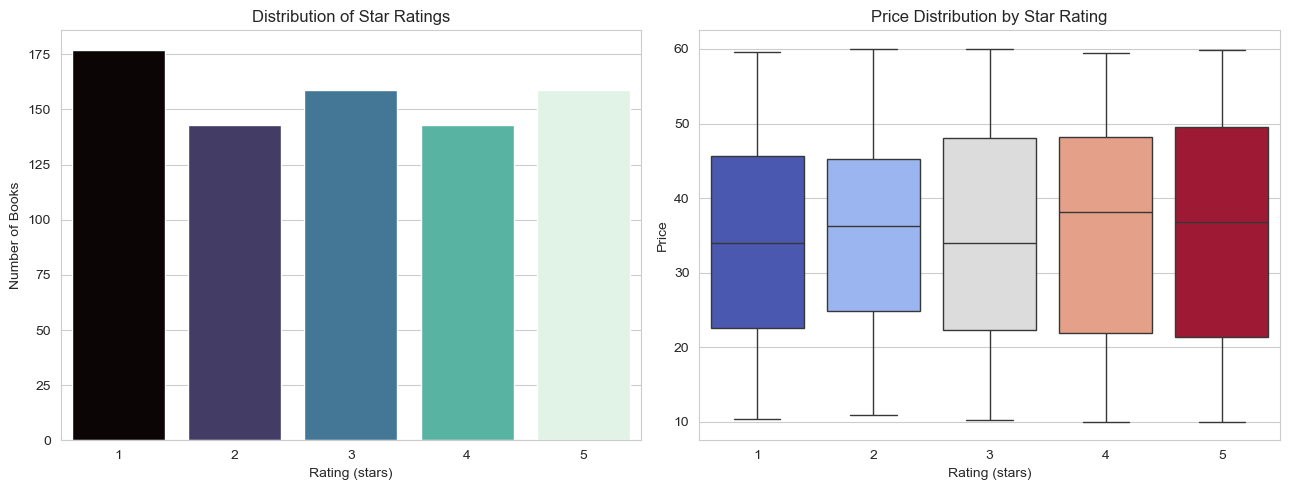

Average price by rating:
rating
1    34.57
2    34.93
3    34.84
4    35.85
5    35.63
Name: price, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=clean_df, x="rating", hue="rating", palette="mako",
              legend=False, ax=axes[0])
axes[0].set_title("Distribution of Star Ratings")
axes[0].set_xlabel("Rating (stars)")
axes[0].set_ylabel("Number of Books")

sns.boxplot(data=clean_df, x="rating", y="price", hue="rating",
            palette="coolwarm", legend=False, ax=axes[1])
axes[1].set_title("Price Distribution by Star Rating")
axes[1].set_xlabel("Rating (stars)")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

print("Average price by rating:")
print(clean_df.groupby("rating")["price"].mean().round(2))

Average price is almost the same at every star rating (34.57 to 35.85). Rating does not seem to affect price.

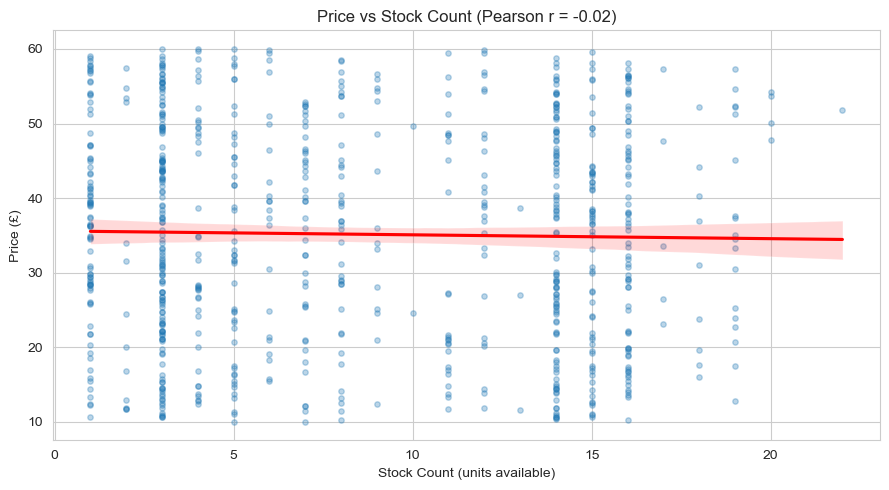

In [19]:
fig, ax = plt.subplots()
sns.regplot(data=clean_df, x="stock_count", y="price",
            scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"}, ax=ax)

corr = clean_df["price"].corr(clean_df["stock_count"])
ax.set_title(f"Price vs Stock Count (Pearson r = {corr:.2f})")
ax.set_xlabel("Stock Count (units available)")
ax.set_ylabel("Price (£)")
plt.tight_layout()
plt.show()

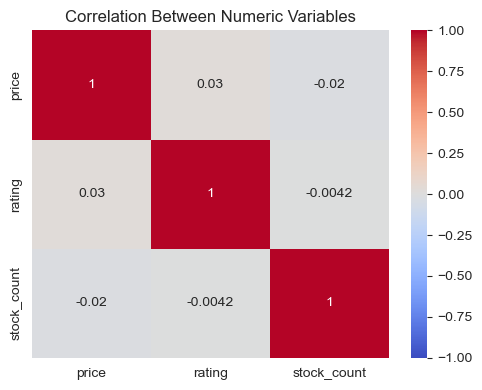

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = clean_df[["price", "rating", "stock_count"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

Price, rating and stock count all have correlations close to zero, so there are no strong linear relationships between them.

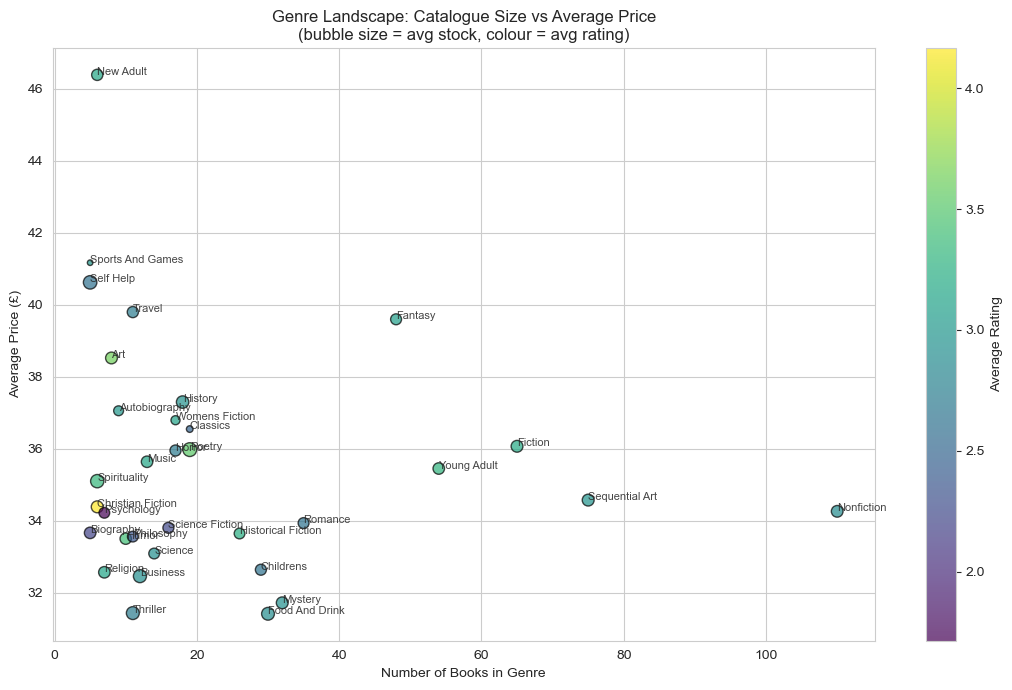

In [21]:
genre_summary = clean_df.groupby("genre").agg(
    avg_price=("price", "mean"),
    num_books=("title", "count"),
    avg_stock=("stock_count", "mean"),
    avg_rating=("rating", "mean"),
).reset_index()
genre_summary = genre_summary[genre_summary["num_books"] >= 5]

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    genre_summary["num_books"], genre_summary["avg_price"],
    s=genre_summary["avg_stock"] * 8, c=genre_summary["avg_rating"],
    cmap="viridis", alpha=0.7, edgecolors="black",
)
for _, row in genre_summary.iterrows():
    ax.annotate(row["genre"], (row["num_books"], row["avg_price"]), fontsize=8, alpha=0.85)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Average Rating")
ax.set_title("Genre Landscape: Catalogue Size vs Average Price\n"
             "(bubble size = avg stock, colour = avg rating)")
ax.set_xlabel("Number of Books in Genre")
ax.set_ylabel("Average Price (£)")
plt.tight_layout()
plt.show()

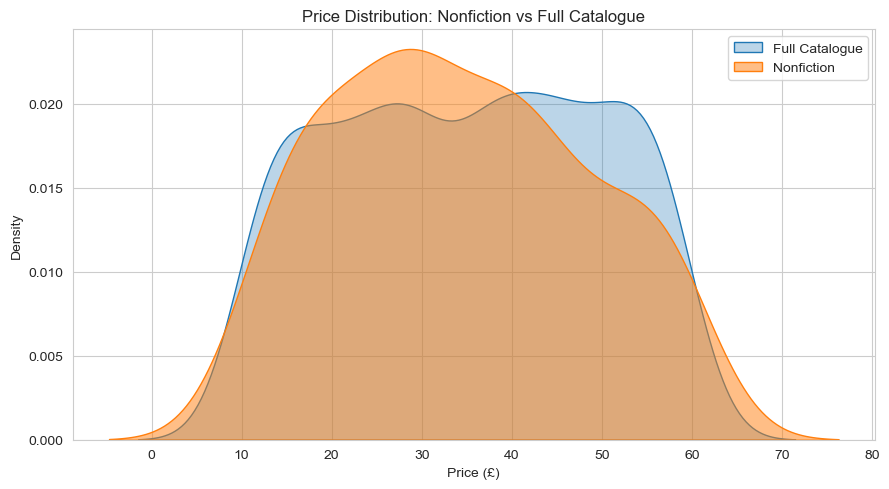

Nonfiction average price: £34.26
Full catalogue average price: £35.14
Nonfiction is -2.5% relative to the catalogue average


In [22]:
fig, ax = plt.subplots()
sns.kdeplot(clean_df["price"], label="Full Catalogue", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(clean_df.loc[clean_df["genre"] == chosen_genre, "price"],
            label=chosen_genre, fill=True, alpha=0.5, ax=ax)
ax.set_title(f"Price Distribution: {chosen_genre} vs Full Catalogue")
ax.set_xlabel("Price (£)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

catalogue_mean = clean_df["price"].mean()
genre_mean = clean_df.loc[clean_df["genre"] == chosen_genre, "price"].mean()
diff_pct = (genre_mean - catalogue_mean) / catalogue_mean * 100
print(f"{chosen_genre} average price: £{genre_mean:.2f}")
print(f"Full catalogue average price: £{catalogue_mean:.2f}")
print(f"{chosen_genre} is {diff_pct:+.1f}% relative to the catalogue average")

Nonfiction is 2.5% cheaper than the catalogue average which is a very small difference.

## 4. Predictive Modeling

In [23]:
print(clean_df["in_stock"].value_counts())
features = ["rating", "stock_count", "genre"]
X = clean_df[features]
y = clean_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining rows: {len(X_train)} | Test rows: {len(X_test)}")

in_stock
True    781
Name: count, dtype: int64

Training rows: 624 | Test rows: 157


I used rating, stock count and genre to predict price. 'in_stock' was left out because all 781 books are in stock so it is the same for every book.

In [24]:
preprocessor = ColumnTransformer(
    transformers=[("genre", OneHotEncoder(handle_unknown="ignore"), ["genre"])],
    remainder="passthrough",
)
model = Pipeline([
    ("prep", preprocessor),
    ("regression", LinearRegression()),
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [26]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"MAE (average error): {mae:.2f}")
print(f"RMSE (penalises big errors): {rmse:.2f}")
print(f"R2 (variance explained): {r2:.3f}")
print(f"\nBaseline MAE: {baseline_mae:.2f}")

MAE (average error): 13.31
RMSE (penalises big errors): 15.72
R2 (variance explained): -0.128

Baseline MAE: 12.81


The model's R^2 is negative and its errors are larger than the baseline's so it predicts worse than simply the average price.

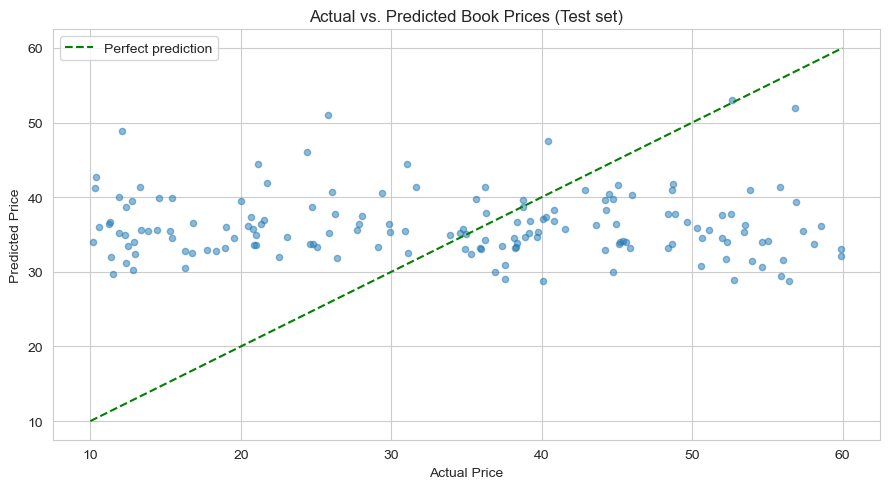

In [27]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.5, s=20)

lims = [y.min(), y.max()]
ax.plot(lims, lims, color="green", linestyle="--", label="Perfect prediction")

ax.set_title("Actual vs. Predicted Book Prices (Test set)")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
coefs = model.named_steps["regression"].coef_
names = model.named_steps["prep"].get_feature_names_out()

coef_df = pd.DataFrame({"feature": names, "coefficient": coefs})
numeric_coefs = coef_df[coef_df["feature"].str.contains("rating|stock_count")]
print(numeric_coefs.to_string(index=False))

               feature  coefficient
     remainder__rating     0.441828
remainder__stock_count    -0.159210
